In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate

from datasets import load_dataset
from utils.func import read_jsonl, softmax
from utils.metric import evaluate
from sklearn.metrics import f1_score, precision_recall_curve, accuracy_score
model_name = "LLaVA-7B"

# data = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")
# len(data)

### Please evaluate the results use the codes provided by the MathVista repo
After that, you can run the following codes

In [7]:
fix = "_oeh"

def save_output():
    dataset = load_dataset("AI4Math/MathVista", split='testmini')
    logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")
    res = {}
    for pid in range(len(dataset)):
        dic = dataset[pid]
        del dic['decoded_image']
        dic['response'] = logits[pid]['response']   # <-- get from logits JSONL
        res[pid+1] = dic

    json.dump(res, open(f"./output/{model_name}/MathV{fix}_output.json", 'w'))

save_output()

# reload
data = json.load(open(f"./output/{model_name}/MathV{fix}_output.json"))
logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score
from scipy.special import softmax
import numpy as np

X = np.array([ins['logits'] for ins in logits])

y = np.array([
    1 if str(data[str(i)]["response"]).strip() == str(data[str(i)]["answer"]).strip() else 0
    for i in range(1, 1001)
])
model = LogisticRegression(class_weight='balanced', penalty='elasticnet', solver='saga', C=0.8, l1_ratio=0.5, max_iter=200)
res = cross_validate(model, X, y, cv=10, scoring=('roc_auc', 'accuracy', 'f1'))
print(res['test_roc_auc'])
print(res['test_accuracy'])
print(res['test_f1'])

print(f"AUROC: {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC: {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1: {np.mean(res['test_f1'])*100:.2f}")
import collections
print(collections.Counter(y))
from sklearn.metrics import precision_recall_curve

y_proba = cross_val_predict(model, X, y, cv=10, method="predict_proba")[:, 1]
prec, rec, thresh = precision_recall_curve(y, y_proba)

f1_scores = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.argmax(f1_scores)
# Compute accuracy for each threshold
acc_scores = []
for t in thresh:
    y_pred = (y_proba >= t).astype(int)
    acc = accuracy_score(y, y_pred)
    acc_scores.append(acc)

# Accuracy at best F1 threshold
best_thresh = thresh[best_idx]
best_f1 = f1_scores[best_idx]
best_acc = acc_scores[best_idx]

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)
print("Accuracy at best F1 threshold:", best_acc)

# (Optional) show some sample thresholds and accuracies
for i in np.linspace(0, len(thresh)-1, 5, dtype=int):
    print(f"Threshold={thresh[i]:.3f}, Accuracy={acc_scores[i]*100:.2f}%")
    
# (Optional) print a few threshold–accuracy pairs
for i in np.linspace(0, len(thresh)-1, 5, dtype=int):
    print(f"Threshold={thresh[i]:.3f}, Accuracy={acc_scores[i]*100:.2f}%")

import collections
print(collections.Counter(y))

0it [00:00, ?it/s]

0it [00:00, ?it/s]

[0.74456522 0.86820652 0.90353261 0.84375    0.71331522 0.89133089
 0.83394383 0.75335775 0.92307692 0.81929182]
[0.81 0.85 0.9  0.88 0.83 0.87 0.9  0.81 0.88 0.85]
[0.24       0.44444444 0.5        0.45454545 0.32       0.51851852
 0.54545455 0.34482759 0.57142857 0.4       ]
AUROC: 82.94
ACC: 85.80
F1: 43.39
Counter({0: 915, 1: 85})
Best threshold: 0.6907388363975725
Best F1: 0.48888888390432106
Accuracy at best F1 threshold: 0.908
Threshold=0.000, Accuracy=8.50%
Threshold=0.006, Accuracy=32.80%
Threshold=0.049, Accuracy=56.40%
Threshold=0.277, Accuracy=78.60%
Threshold=0.997, Accuracy=91.40%
Threshold=0.000, Accuracy=8.50%
Threshold=0.006, Accuracy=32.80%
Threshold=0.049, Accuracy=56.40%
Threshold=0.277, Accuracy=78.60%
Threshold=0.997, Accuracy=91.40%
Counter({0: 915, 1: 85})


## OE

In [25]:
fix = "_oe"

def save_output():
    dataset = load_dataset("AI4Math/MathVista", split='testmini')
    logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")
    res = {}
    for pid in range(len(dataset)):
        dic = dataset[pid]
        del dic['decoded_image']
        dic['response'] = logits[pid]['response']   # <-- get from logits JSONL
        res[pid+1] = dic

    json.dump(res, open(f"./output/{model_name}/MathV{fix}_output.json", 'w'))

save_output()

# reload
data = json.load(open(f"./output/{model_name}/MathV{fix}_output.json"))
logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score
from scipy.special import softmax
import numpy as np

X = np.array([ins['logits'] for ins in logits])

y = np.array([
    1 if str(data[str(i)]["response"]).strip() == str(data[str(i)]["answer"]).strip() else 0
    for i in range(1, 1001)
])
model = LogisticRegression(class_weight='balanced')
res = cross_validate(model, X, y, cv=10, scoring=('roc_auc', 'accuracy', 'f1'))
print(res['test_roc_auc'])
print(res['test_accuracy'])
print(res['test_f1'])

print(f"AUROC: {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC: {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1: {np.mean(res['test_f1'])*100:.2f}")
from sklearn.metrics import precision_recall_curve

y_proba = cross_val_predict(model, X, y, cv=10, method="predict_proba")[:, 1]
prec, rec, thresh = precision_recall_curve(y, y_proba)

f1_scores = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.argmax(f1_scores)

print("Best threshold:", thresh[best_idx])
print("Best F1:", f1_scores[best_idx])
import collections
print(collections.Counter(y))

0it [00:00, ?it/s]

0it [00:00, ?it/s]

[0.8046875  0.87239583 0.93489583 0.63020833 0.91666667 0.734375
 0.77604167 0.77263158 0.86315789 0.58947368]
[0.94 0.91 0.95 0.95 0.94 0.92 0.92 0.94 0.93 0.93]
[0.25       0.         0.         0.         0.25       0.2
 0.         0.25       0.36363636 0.        ]
AUROC: 78.95
ACC: 93.30
F1: 13.14
Best threshold: 0.0002171182457719783
Best F1: 0.30263157489006237
Counter({0: 957, 1: 43})


In [ ]:
# fintune
from sklearn.metrics import accuracy_score

fix = "_oe"

def save_output():
    dataset = load_dataset("AI4Math/MathVista", split='testmini')
    logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")
    res = {}
    for pid in range(len(dataset)):
        dic = dataset[pid]
        del dic['decoded_image']
        dic['response'] = logits[pid]['response']   # <-- get from logits JSONL
        res[pid+1] = dic

    json.dump(res, open(f"./output/{model_name}/MathV{fix}_output.json", 'w'))

save_output()

# reload
data = json.load(open(f"./output/{model_name}/MathV{fix}_output.json"))
logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.metrics import f1_score, precision_recall_curve, accuracy_score
import numpy as np, collections

X = np.array([ins['logits'] for ins in logits])

y = np.array([
    1 if str(data[str(i)]["response"]).strip() == str(data[str(i)]["answer"]).strip() else 0
    for i in range(1, 1001)
])

model = LogisticRegression(class_weight='balanced', penalty='elasticnet', solver='saga', C=0.8, l1_ratio=0.5, max_iter=2000)
res = cross_validate(model, X, y, cv=10, scoring=('roc_auc', 'accuracy', 'f1'))
print(f"AUROC (CV mean): {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC   (CV mean): {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1    (CV mean): {np.mean(res['test_f1'])*100:.2f}")

# ---- threshold tuning on all data ----
y_proba = cross_val_predict(model, X, y, cv=10, method="predict_proba")[:, 1]
prec, rec, thresh = precision_recall_curve(y, y_proba)

f1_scores = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.argmax(f1_scores)
best_thr = thresh[best_idx]

print("Best threshold:", best_thr)
print("Best F1:", f1_scores[best_idx])

# apply threshold to get predictions
custom_pred = (y_proba >= best_thr).astype(int)

print("ACC @best_thr:", accuracy_score(y, custom_pred))
print("F1  @best_thr:", f1_score(y, custom_pred))

print(collections.Counter(y))


0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [35]:
# grid search
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

# Assuming X_train, y_train, X_test, y_test are already defined

# Example of hyperparameter tuning with GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'], # 'liblinear' supports both 'l1' and 'l2'
    'class_weight': [None, 'balanced']
}

logistic_model = LogisticRegression(random_state=42)
grid_search = GridSearchCV(logistic_model, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X, y)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred)
print(f"Best F1 score: {f1}")
print(f"Best parameters: {grid_search.best_params_}")

NameError: name 'X_test' is not defined

In [21]:
import json
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# Path to your self-eval file
file_path = "./output/LLaVA-7B/MathV_self_eval.jsonl"

labels = []
scores = []

# Load JSONL file
with open(file_path) as f:
    for line in f:
        ins = json.loads(line)
        
        # Ground truth: if label is "Unanswerable" treat as 0, otherwise 1
        # (adjust depending on your dataset convention)
        gt = 0 if str(ins["label"]).lower() in ["unanswerable", "0"] else 1
        
        # Model response: float from string
        try:
            pred = float(str(ins["response"]).strip().split()[0])
        except:
            pred = 0.0  # fallback if parsing fails
            print("strange")
        
        labels.append(gt)
        scores.append(pred)

labels = np.array(labels)
scores = np.array(scores)

# Binarize predictions with threshold 0.5
preds = (scores >= 0.0001).astype(int)

# Compute metrics
auroc = roc_auc_score(labels, scores)
acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds)

print(f"AUROC: {auroc*100:.2f}")
print(f"ACC: {acc*100:.2f}")
print(f"F1: {f1*100:.2f}")
# import collections
# print(collections.Counter(y))

AUROC: 67.97
ACC: 54.60
F1: 69.81


In [30]:
import json
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# Path to your self-eval file
file_path = "./output/LLaVA-7B/MathV_oeh.jsonl"

labels = []
scores = []

# Load JSONL file
with open(file_path) as f:
    for line in f:
        ins = json.loads(line)
        
        # Ground truth: if label is "Unanswerable" treat as 0, otherwise 1
        # (adjust depending on your dataset convention)
        gt = 0 if str(ins["label"]).lower() in ["unanswerable", "0"] else 1
        
        # Model response: float from string
        try:
            pred = float(str(ins["response"]).strip().split()[0])
        except:
            pred = 0.0  # fallback if parsing fails
        
        labels.append(gt)
        scores.append(pred)

labels = np.array(labels)
scores = np.array(scores)

# Binarize predictions with threshold 0.5
preds = (scores >= 0.5).astype(int)

# Compute metrics
auroc = roc_auc_score(labels, scores)
acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds)

print(f"AUROC: {auroc*100:.2f}")
print(f"ACC: {acc*100:.2f}")
print(f"F1: {f1*100:.2f}")


AUROC: 41.84
ACC: 36.10
F1: 52.42


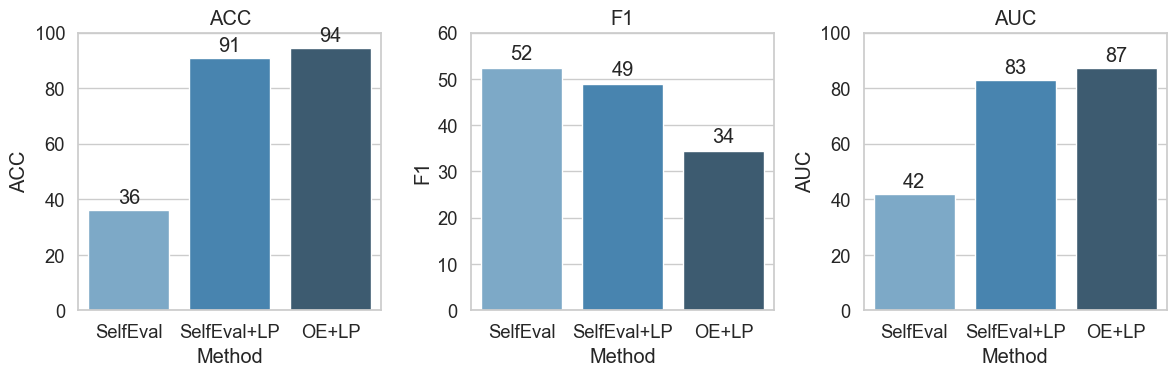

In [5]:
# after finetuning
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your results
data = {
    "Method": ["SelfEval", "SelfEval+LP", "OE+LP"],
    "ACC": [36.10, 90.80, 94.30],
    "F1": [52.42, 48.88, 34.48],
    "AUC": [41.84, 82.94, 87.10],
}

df = pd.DataFrame(data)

# Plot style
sns.set(style="whitegrid", font_scale=1.2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# ACC plot
sns.barplot(ax=axes[0], x="Method", y="ACC", data=df, palette="Blues_d")
for idx, val in enumerate(df["ACC"]):
    axes[0].text(idx, val + 1, f"{val:.0f}", ha="center", va="bottom")
axes[0].set_ylim(0, 100)

# F1 plot
sns.barplot(ax=axes[1], x="Method", y="F1", data=df, palette="Blues_d")
for idx, val in enumerate(df["F1"]):
    axes[1].text(idx, val + 1, f"{val:.0f}", ha="center", va="bottom")
axes[1].set_ylim(0, 60)

# AUC plot
sns.barplot(ax=axes[2], x="Method", y="AUC", data=df, palette="Blues_d")
for idx, val in enumerate(df["AUC"]):
    axes[2].text(idx, val + 1, f"{val:.0f}", ha="center", va="bottom")
axes[2].set_ylim(0, 100)

# Titles
axes[0].set_title("ACC")
axes[1].set_title("F1")
axes[2].set_title("AUC")

plt.tight_layout()
plt.show()


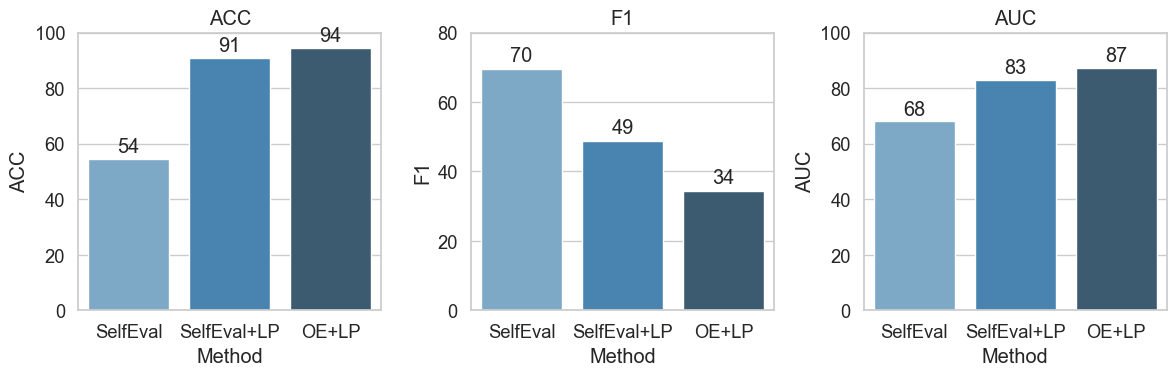

In [24]:
# AUROC: 67.97
#ACC: 54.30
#F1: 69.55
# after finetuning
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your results
data = {
    "Method": ["SelfEval", "SelfEval+LP", "OE+LP"],
    "ACC": [54.30, 90.80, 94.30],
    "F1": [69.55, 48.88, 34.48],
    "AUC": [67.97, 82.94, 87.10],
}

df = pd.DataFrame(data)

# Plot style
sns.set(style="whitegrid", font_scale=1.2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# ACC plot
sns.barplot(ax=axes[0], x="Method", y="ACC", data=df, palette="Blues_d")
for idx, val in enumerate(df["ACC"]):
    axes[0].text(idx, val + 1, f"{val:.0f}", ha="center", va="bottom")
axes[0].set_ylim(0, 100)

# F1 plot
sns.barplot(ax=axes[1], x="Method", y="F1", data=df, palette="Blues_d")
for idx, val in enumerate(df["F1"]):
    axes[1].text(idx, val + 1, f"{val:.0f}", ha="center", va="bottom")
axes[1].set_ylim(0, 80)

# AUC plot
sns.barplot(ax=axes[2], x="Method", y="AUC", data=df, palette="Blues_d")
for idx, val in enumerate(df["AUC"]):
    axes[2].text(idx, val + 1, f"{val:.0f}", ha="center", va="bottom")
axes[2].set_ylim(0, 100)

# Titles
axes[0].set_title("ACC")
axes[1].set_title("F1")
axes[2].set_title("AUC")

plt.tight_layout()
plt.show()


In [11]:
# train a xgboost
from xgboost import XGBClassifier
fix = "_oe"

def save_output():
    dataset = load_dataset("AI4Math/MathVista", split='testmini')
    logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")
    res = {}
    for pid in range(len(dataset)):
        dic = dataset[pid]
        del dic['decoded_image']
        dic['response'] = logits[pid]['response']   # <-- get from logits JSONL
        res[pid+1] = dic

    json.dump(res, open(f"./output/{model_name}/MathV{fix}_output.json", 'w'))

save_output()

# reload
data = json.load(open(f"./output/{model_name}/MathV{fix}_output.json"))
logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score
from scipy.special import softmax
import numpy as np

X = np.array([ins['logits'] for ins in logits])

y = np.array([
    1 if str(data[str(i)]["response"]).strip() == str(data[str(i)]["answer"]).strip() else 0
    for i in range(1, 1001)
])
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=(len(y) - sum(y)) / sum(y),  # handle imbalance like class_weight
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

res = cross_validate(model, X, y, cv=10, scoring=('roc_auc', 'accuracy', 'f1'))
print(res['test_roc_auc'])
print(res['test_accuracy'])
print(res['test_f1'])

print(f"AUROC: {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC: {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1: {np.mean(res['test_f1'])*100:.2f}")
from sklearn.metrics import precision_recall_curve

y_proba = cross_val_predict(model, X, y, cv=10, method="predict_proba")[:, 1]
prec, rec, thresh = precision_recall_curve(y, y_proba)

f1_scores = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.argmax(f1_scores)

print("Best threshold:", thresh[best_idx])
print("Best F1:", f1_scores[best_idx])
import collections
print(collections.Counter(y))


0it [00:00, ?it/s]

0it [00:00, ?it/s]

[0.81770833 0.87760417 0.87239583 0.7734375  0.84895833 0.68489583
 0.8046875  0.74947368 0.93052632 0.80210526]
[0.96 0.95 0.97 0.96 0.97 0.95 0.94 0.96 0.93 0.94]
[0.         0.         0.4        0.         0.57142857 0.
 0.         0.33333333 0.         0.        ]
AUROC: 81.62
ACC: 95.30
F1: 13.05
Best threshold: 0.009887719
Best F1: 0.24561403202716223
Counter({0: 957, 1: 43})


In [2]:
# more data
import sklearn

fix = "_oe"

def save_output():
    dataset = load_dataset("AI4Math/MathVista", split='testmini')
    logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")
    res = {}
    for pid in range(len(dataset)):
        dic = dataset[pid]
        del dic['decoded_image']
        dic['response'] = logits[pid]['response']   # <-- get from logits JSONL
        res[pid+1] = dic

    json.dump(res, open(f"./output/{model_name}/MathV{fix}_output.json", 'w'))

save_output()

# reload
data = json.load(open(f"./output/{model_name}/MathV{fix}_output.json"))
logits = read_jsonl(f"./output/{model_name}/MathV{fix}.jsonl")


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score
from scipy.special import softmax
import numpy as np

X = np.array([ins['logits'] for ins in logits])

y = np.array([
    1 if str(data[str(i)]["response"]).strip() == str(data[str(i)]["answer"]).strip() else 0
    for i in range(1, 1001)
])

from imblearn.over_sampling import SMOTE
X_res, y_res = SMOTE().fit_resample(X, y)

print(y_res)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

[0 1 0 ... 1 1 1]


In [5]:
import collections
print(collections.Counter(y_res))


Counter({0: 957, 1: 957})


In [6]:
# fintune
from sklearn.metrics import accuracy_score

fix = "_oe"

model = LogisticRegression(class_weight='balanced', penalty='elasticnet', solver='saga', C=0.2, l1_ratio=0.5)
res = cross_validate(model, X_res, y_res, cv=10, scoring=('roc_auc', 'accuracy', 'f1'))
print(res['test_roc_auc'])
print(res['test_accuracy'])
print(res['test_f1'])

print(f"AUROC: {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC: {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1: {np.mean(res['test_f1'])*100:.2f}")
import collections
print(collections.Counter(y_res))
from sklearn.metrics import precision_recall_curve

y_proba = cross_val_predict(model, X_res, y_res, cv=10, method="predict_proba")[:, 1]
prec, rec, thresh = precision_recall_curve(y_res, y_proba)

f1_scores = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.argmax(f1_scores)
# Compute accuracy for each threshold
acc_scores = []
for t in thresh:
    y_pred = (y_proba >= t).astype(int)
    acc = accuracy_score(y_res, y_pred)
    acc_scores.append(acc)

# Accuracy at best F1 threshold
best_thresh = thresh[best_idx]
best_f1 = f1_scores[best_idx]
best_acc = acc_scores[best_idx]

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)
print("Accuracy at best F1 threshold:", best_acc)

# (Optional) show some sample thresholds and accuracies
for i in np.linspace(0, len(thresh)-1, 5, dtype=int):
    print(f"Threshold={thresh[i]:.3f}, Accuracy={acc_scores[i]*100:.2f}%")
    
# (Optional) print a few threshold–accuracy pairs
for i in np.linspace(0, len(thresh)-1, 5, dtype=int):
    print(f"Threshold={thresh[i]:.3f}, Accuracy={acc_scores[i]*100:.2f}%")

import collections
print(collections.Counter(y_res))

[0.99620226 0.99251302 0.99956597 0.99815538 0.99287281 0.98475877
 0.98190789 0.99714912 0.99934211 0.98881579]
[0.95833333 0.953125   0.97916667 0.96875    0.96858639 0.96335079
 0.96335079 0.97905759 0.97905759 0.97382199]
[0.95959596 0.95522388 0.97959184 0.96969697 0.96938776 0.96446701
 0.96446701 0.97959184 0.97959184 0.97461929]
AUROC: 99.31
ACC: 96.87
F1: 96.96
Counter({0: 957, 1: 957})
Best threshold: 0.6234035078226513
Best F1: 0.9738327297373743
Accuracy at best F1 threshold: 0.9733542319749217
Threshold=0.000, Accuracy=50.00%
Threshold=0.011, Accuracy=74.97%
Threshold=0.725, Accuracy=96.60%
Threshold=0.956, Accuracy=74.66%
Threshold=0.991, Accuracy=50.05%
Threshold=0.000, Accuracy=50.00%
Threshold=0.011, Accuracy=74.97%
Threshold=0.725, Accuracy=96.60%
Threshold=0.956, Accuracy=74.66%
Threshold=0.991, Accuracy=50.05%
Counter({0: 957, 1: 957})


In [3]:
# Train with SMOTE on each training fold, validate on original folds
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve, roc_auc_score
import numpy as np
import collections

print("Class balance (original):", collections.Counter(y))

# 1) Build a CV that shuffles
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 2) Pipeline: scale -> SMOTE (on train folds only) -> classifier
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(
        class_weight='balanced',
        penalty='elasticnet',
        solver='saga',
        C=0.2,
        l1_ratio=0.5,
        random_state=42
    ))
])

# 3) Cross-validated metrics (val folds are original data)
res = cross_validate(pipe, X, y, cv=cv, scoring=('roc_auc','accuracy','f1'))
print("\n--- Cross-validation (train=SMOTE, val=original) ---")
print(f"AUROC (CV mean): {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC   (CV mean): {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1    (CV mean): {np.mean(res['test_f1'])*100:.2f}")

# 4) Get out-of-fold probabilities on ORIGINAL data (each fold trained with SMOTE)
y_proba_oof = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]

# 5) Tune threshold FAIRLY using only these out-of-fold probs
prec, rec, thresh = precision_recall_curve(y, y_proba_oof)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.argmax(f1_scores)
best_thr = thresh[best_idx]

# 6) Report metrics at the tuned threshold (still all OOF)
y_pred_oof = (y_proba_oof >= best_thr).astype(int)
print(f"\nBest threshold (OOF): {best_thr:.4f}")
print(f"F1 @best_thr (OOF):   {f1_score(y, y_pred_oof)*100:.2f}")
print(f"ACC @best_thr (OOF):  {accuracy_score(y, y_pred_oof)*100:.2f}")
print(f"AUROC (OOF):          {roc_auc_score(y, y_proba_oof)*100:.2f}")


Class balance (original): Counter({0: 957, 1: 43})

--- Cross-validation (train=SMOTE, val=original) ---
AUROC (CV mean): 81.08
ACC   (CV mean): 79.50
F1    (CV mean): 22.97

Best threshold (OOF): 0.7111
F1 @best_thr (OOF):   32.84
ACC @best_thr (OOF):  91.00
AUROC (OOF):          80.52


In [ ]:
# fintune
from sklearn.metrics import accuracy_score

fix = "_oeh"

model = LogisticRegression(class_weight='balanced', penalty='elasticnet', solver='saga', C=0.8, l1_ratio=0.5)
res = cross_validate(model, X_res, y_res, cv=10, scoring=('roc_auc', 'accuracy', 'f1'))
print(res['test_roc_auc'])
print(res['test_accuracy'])
print(res['test_f1'])

print(f"AUROC: {np.mean(res['test_roc_auc'])*100:.2f}")
print(f"ACC: {np.mean(res['test_accuracy'])*100:.2f}")
print(f"F1: {np.mean(res['test_f1'])*100:.2f}")
import collections
print(collections.Counter(y_res))
from sklearn.metrics import precision_recall_curve

y_proba = cross_val_predict(model, X_res, y_res, cv=10, method="predict_proba")[:, 1]
prec, rec, thresh = precision_recall_curve(y_res, y_proba)

f1_scores = 2 * (prec * rec) / (prec + rec + 1e-8)
best_idx = np.argmax(f1_scores)
# Compute accuracy for each threshold
acc_scores = []
for t in thresh:
    y_pred = (y_proba >= t).astype(int)
    acc = accuracy_score(y_res, y_pred)
    acc_scores.append(acc)

# Accuracy at best F1 threshold
best_thresh = thresh[best_idx]
best_f1 = f1_scores[best_idx]
best_acc = acc_scores[best_idx]

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)
print("Accuracy at best F1 threshold:", best_acc)

# (Optional) show some sample thresholds and accuracies
for i in np.linspace(0, len(thresh)-1, 5, dtype=int):
    print(f"Threshold={thresh[i]:.3f}, Accuracy={acc_scores[i]*100:.2f}%")
    
# (Optional) print a few threshold–accuracy pairs
for i in np.linspace(0, len(thresh)-1, 5, dtype=int):
    print(f"Threshold={thresh[i]:.3f}, Accuracy={acc_scores[i]*100:.2f}%")

import collections
print(collections.Counter(y_res))